# Türkçe Hibrit Anonimleştirme — Veri Analizi ve Model Değerlendirme

Bu notebook:

1. `data/*.jsonl` altındaki karakter konumlu veri setlerini bulur ve doğrular.
2. Veri setinin metin, entity ve sınıf dağılımlarını tablo ve grafiklerle gösterir.
3. Regex/kurallar, Presidio, GLiNER ve Türkçe NER (ModernBERT) katmanlarını ayrı ayrı çalıştırır.
4. Her modül ve entity sınıfı için `TP`, `FP`, `FN`, precision, recall ve F1 hesaplar.
5. Çalışabilen katmanları birleştirerek hibrit pipeline'ı değerlendirir.
6. Tüm metinlerin maskelenmiş halini ve `start_char`, `end_char`, `model`, `entity_class` JSON çıktısını gösterir.
7. Sonuçları `outputs/notebook_analysis/` klasörüne kaydeder.

**Eşleşme ölçütü:** Tahmin ancak `start`, `end` ve `label` değerlerinin üçü de altın etiketle aynıysa doğru sayılır. Kısmi veya sınıfı farklı eşleşme bir yanlış pozitif ve bir kaçırılmış entity üretir.

> Model hücreleri ilk çalıştırmada ağırlık indirebilir. Kurumsal veya çevrimdışı kullanımda onaylı yerel model yollarını `ANON_GLINER_MODEL` ve `ANON_NER_MODEL` ortam değişkenleriyle belirtin.

## 1. Ortam ve çalışma ayarları

Notebook proje kökünü otomatik bulur. Yeni JSONL dosyaları `data/` klasörüne eklendiğinde varsayılan `data/*.jsonl` deseniyle analize dahil edilir. Yalnız belirli dosyaları kullanmak isterseniz `DATA_GLOB` değerini değiştirin.

In [1]:
from __future__ import annotations

import json
import os
import sys
import time
from collections import Counter, defaultdict
from html import escape
from pathlib import Path

try:
    import pandas as pd
    import matplotlib.pyplot as plt
    from IPython.display import HTML, Markdown, display
except ImportError as exc:
    raise ImportError(
        "Notebook bağımlılıkları eksik. Proje kökünde "
        "pip install -e '.[presidio,models,analysis]' komutunu çalıştırın."
    ) from exc


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "hybrid_anon").exists():
            return candidate.resolve()
    raise FileNotFoundError("pyproject.toml ve src/hybrid_anon içeren proje kökü bulunamadı.")


ROOT = find_project_root()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

DATA_GLOB = "data/*.jsonl"
THRESHOLD = 0.50
OFFLINE_MODE = False
LOCAL_LLM_MODEL = None  # Örnek: "qwen2.5:7b"; Ollama yerelde çalışıyor olmalıdır.
OUTPUT_DIR = ROOT / "outputs" / "notebook_analysis"

os.environ.setdefault("HF_HOME", str(ROOT / ".model_cache"))
if OFFLINE_MODE:
    os.environ["HF_HUB_OFFLINE"] = "1"

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 200)
plt.style.use("seaborn-v0_8-whitegrid")

print(f"Proje kökü : {ROOT.name}")
print(f"Veri deseni: {DATA_GLOB}")
print(f"Eşik        : {THRESHOLD}")
print(f"Model cache : {Path(os.environ['HF_HOME']).name}")

Proje kökü : <PROJECT_ROOT>
Veri deseni: data/*.jsonl
Eşik        : 0.5
Model cache : <PROJECT_ROOT>\.model_cache


## 2. Veri setini yükleme ve doğrulama

Beklenen her JSONL satırı `id`, `text` ve `entities` alanlarını içerir. Entity kaydı `start`, `end`, `label` biçiminde olmalıdır. Notebook ileriye dönük olarak `start_char`, `end_char`, `entity_class` alanlarını da kabul eder.

In [2]:
def normalize_entity(entity: dict) -> dict:
    return {
        "start": entity.get("start", entity.get("start_char")),
        "end": entity.get("end", entity.get("end_char")),
        "label": entity.get("label", entity.get("entity_class")),
    }


def load_dataset(root: Path, pattern: str):
    files = sorted(root.glob(pattern))
    if not files:
        raise FileNotFoundError(f"Veri dosyası bulunamadı: {root / pattern}")
    rows, errors = [], []
    seen_keys = set()
    for path in files:
        with path.open(encoding="utf-8") as stream:
            for line_no, line in enumerate(stream, 1):
                if not line.strip():
                    continue
                try:
                    raw = json.loads(line)
                except json.JSONDecodeError as exc:
                    errors.append(f"{path.name}:{line_no} geçersiz JSON: {exc}")
                    continue
                text = raw.get("text")
                entities = raw.get("entities")
                row_id = str(raw.get("id", f"{path.stem}_{line_no}"))
                key = f"{path.name}:{line_no}:{row_id}"
                if not isinstance(text, str) or not isinstance(entities, list):
                    errors.append(f"{path.name}:{line_no} text string ve entities liste olmalıdır")
                    continue
                if key in seen_keys:
                    errors.append(f"Tekrarlanan kayıt anahtarı: {key}")
                    continue
                seen_keys.add(key)
                normalized, local_spans = [], set()
                for entity_no, raw_entity in enumerate(entities, 1):
                    if not isinstance(raw_entity, dict):
                        errors.append(f"{path.name}:{line_no} entity {entity_no} nesne değil")
                        continue
                    entity = normalize_entity(raw_entity)
                    start, end, label = entity["start"], entity["end"], entity["label"]
                    if not isinstance(start, int) or not isinstance(end, int) or not isinstance(label, str):
                        errors.append(f"{path.name}:{line_no} entity {entity_no} alan tipleri geçersiz")
                        continue
                    if not (0 <= start < end <= len(text)):
                        errors.append(f"{path.name}:{line_no} entity {entity_no} konumu metin dışında")
                        continue
                    span_key = (start, end, label)
                    if span_key in local_spans:
                        errors.append(f"{path.name}:{line_no} tekrarlanan entity: {span_key}")
                        continue
                    local_spans.add(span_key)
                    normalized.append(entity)
                rows.append({"_key": key, "id": row_id, "text": text, "entities": normalized,
                             "split": str(raw.get("split", "unspecified")),
                             "source_file": path.name, "line_no": line_no})
    if errors:
        preview = "\n".join(f"- {item}" for item in errors[:30])
        raise ValueError(f"Veri doğrulama hataları ({len(errors)}):\n{preview}")
    return files, rows


DATA_FILES, DATASET = load_dataset(ROOT, DATA_GLOB)
document_records, entity_records = [], []
for row in DATASET:
    document_records.append({"key": row["_key"], "id": row["id"], "source_file": row["source_file"],
                             "split": row["split"], "character_count": len(row["text"]),
                             "entity_count": len(row["entities"]), "has_entity": bool(row["entities"])})
    for entity in row["entities"]:
        entity_records.append({"key": row["_key"], "id": row["id"], "source_file": row["source_file"],
                               "split": row["split"], "start": entity["start"], "end": entity["end"],
                               "label": entity["label"], "length": entity["end"] - entity["start"]})

documents_df = pd.DataFrame(document_records)
entities_df = pd.DataFrame(entity_records, columns=["key", "id", "source_file", "split", "start", "end", "label", "length"])
print(f"Okunan dosya sayısı: {len(DATA_FILES)}")
for path in DATA_FILES:
    print(f"- {path.relative_to(ROOT)}")
print(f"Geçerli metin sayısı: {len(DATASET)}")

Okunan dosya sayısı: 1
- data\synthetic_tr.jsonl
Geçerli metin sayısı: 17


## 3. Veri seti özet istatistikleri

Bu bölüm veri büyüdükçe otomatik güncellenir. `support`, altın etiketlerde ilgili sınıftan kaç entity bulunduğunu gösterir.

In [3]:
total_documents = len(documents_df)
total_entities = len(entities_df)
positive_documents = int(documents_df["has_entity"].sum())
negative_documents = total_documents - positive_documents

summary_df = pd.DataFrame([
    {"Metrik": "Metin sayısı", "Değer": total_documents},
    {"Metrik": "Pozitif metin", "Değer": positive_documents},
    {"Metrik": "Negatif metin", "Değer": negative_documents},
    {"Metrik": "Toplam entity", "Değer": total_entities},
    {"Metrik": "Farklı entity sınıfı", "Değer": int(entities_df["label"].nunique()) if total_entities else 0},
    {"Metrik": "Metin başına ortalama entity", "Değer": round(total_entities / total_documents, 3) if total_documents else 0},
    {"Metrik": "Pozitif metin başına ortalama entity", "Değer": round(total_entities / positive_documents, 3) if positive_documents else 0},
    {"Metrik": "Ortalama metin uzunluğu (karakter)", "Değer": round(documents_df["character_count"].mean(), 2)},
])
display(summary_df)

if total_entities:
    entity_distribution_df = (entities_df.groupby("label")
        .agg(support=("label", "size"), document_count=("key", "nunique"), average_span_length=("length", "mean"))
        .reset_index().sort_values(["support", "label"], ascending=[False, True]))
    entity_distribution_df["entity_share_pct"] = (100 * entity_distribution_df["support"] / total_entities).round(2)
    entity_distribution_df["document_coverage_pct"] = (100 * entity_distribution_df["document_count"] / total_documents).round(2)
    entity_distribution_df["average_span_length"] = entity_distribution_df["average_span_length"].round(2)
else:
    entity_distribution_df = pd.DataFrame(columns=["label", "support", "document_count", "average_span_length",
                                                    "entity_share_pct", "document_coverage_pct"])
display(entity_distribution_df)

split_summary_df = (documents_df.groupby(["source_file", "split"])
    .agg(documents=("key", "size"), positive_documents=("has_entity", "sum"), entities=("entity_count", "sum"))
    .reset_index())
display(split_summary_df)

,Metrik,Değer
0,Metin sayısı,17.000
1,Pozitif metin,14.000
2,Negatif metin,3.000
3,Toplam entity,23.000
4,Farklı entity sınıfı,11.000
5,Metin başına ortalama entity,1.353
6,Pozitif metin başına ortalama entity,1.643
7,Ortalama metin uzunluğu (karakter),50.940


,label,support,document_count,average_span_length,entity_share_pct,document_coverage_pct
4,HEALTH_INFORMATION,7,5,9.00,30.43,29.41
6,PERSON,3,3,11.33,13.04,17.65
2,CLAIM_NUMBER,2,2,14.50,8.70,11.76
8,POLICY_NUMBER,2,2,14.00,8.70,11.76
9,TCKN,2,2,11.00,8.70,11.76
10,VEHICLE_PLATE,2,2,10.00,8.70,11.76
0,ADDRESS,1,1,26.00,4.35,5.88
1,BAC_VALUE,1,1,11.00,4.35,5.88
3,EMAIL,1,1,22.00,4.35,5.88
5,IBAN,1,1,32.00,4.35,5.88


,source_file,split,documents,positive_documents,entities
0,synthetic_tr.jsonl,unspecified,17,14,23


## 4. Veri dağılımı grafikleri

Pasta grafik pozitif/negatif metin dengesini, çubuk grafik entity sınıflarının dağılımını, histogram ise metin başına entity sayısını gösterir.

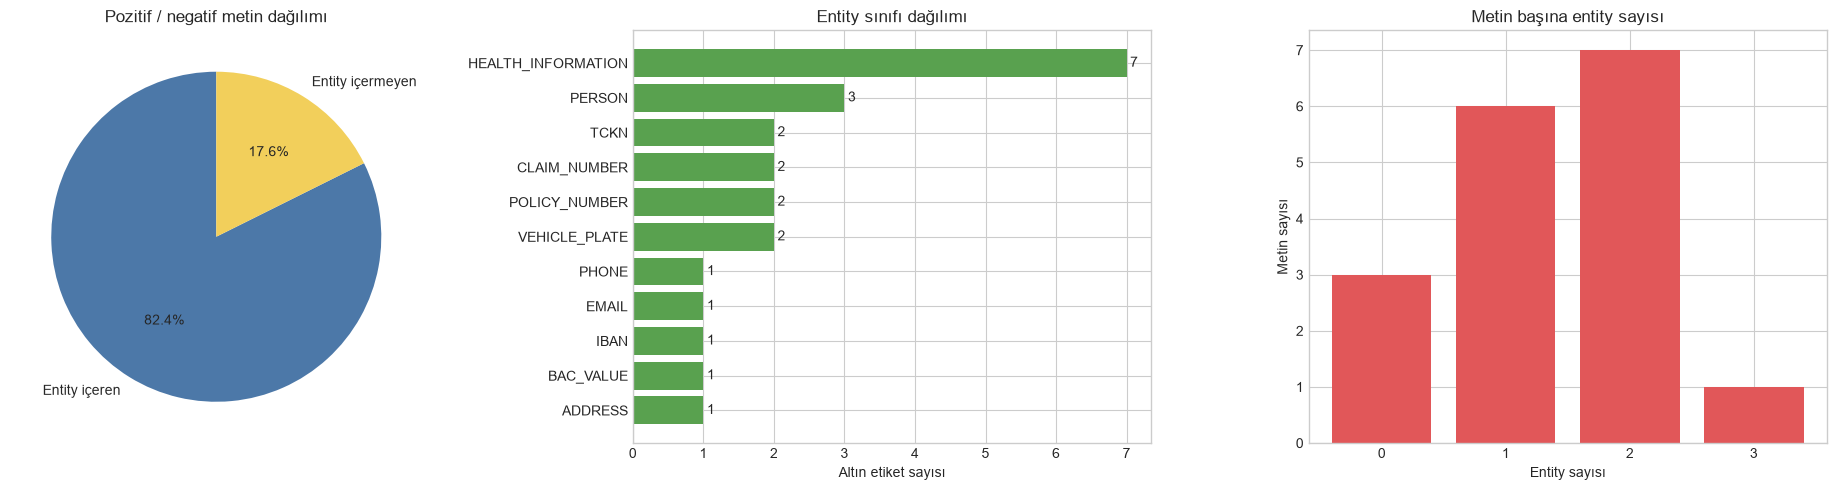

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
pie_values = [positive_documents, negative_documents]
if sum(pie_values):
    axes[0].pie(pie_values, labels=["Entity içeren", "Entity içermeyen"], autopct="%1.1f%%",
                startangle=90, colors=["#4C78A8", "#F2CF5B"])
axes[0].set_title("Pozitif / negatif metin dağılımı")
if not entity_distribution_df.empty:
    plot_df = entity_distribution_df.sort_values("support")
    axes[1].barh(plot_df["label"], plot_df["support"], color="#59A14F")
    for index, value in enumerate(plot_df["support"]):
        axes[1].text(value + 0.05, index, str(value), va="center")
axes[1].set_title("Entity sınıfı dağılımı")
axes[1].set_xlabel("Altın etiket sayısı")
hist_counts = documents_df["entity_count"].value_counts().sort_index()
axes[2].bar(hist_counts.index.astype(str), hist_counts.values, color="#E15759")
axes[2].set_title("Metin başına entity sayısı")
axes[2].set_xlabel("Entity sayısı")
axes[2].set_ylabel("Metin sayısı")
plt.tight_layout()
plt.show()

## 5. Değerlendirme yardımcıları

- **TP (doğru):** Konum ve sınıfı altın etiketle tam eşleşen tahmin.
- **FP (fazladan/yanlış):** Veri setinde karşılığı olmayan tahmin.
- **FN (kaçırılan):** Veri setinde olduğu halde bulunamayan entity.
- **Precision:** `TP / (TP + FP)`
- **Recall:** `TP / (TP + FN)`
- **F1:** Precision ve recall'un harmonik ortalaması.

Her modül kendi başına çalıştırılır. Böylece modül sonucu hibrit çakışma çözümünde başka bir modül tarafından bastırılmadan ölçülür.

In [5]:
from hybrid_anon.pipeline import detect


def safe_ratio(numerator: int, denominator: int) -> float:
    return numerator / denominator if denominator else 0.0


def evaluate_prediction_map(name: str, engines: tuple[str, ...], predictions: dict, elapsed: float) -> dict:
    totals, label_counts, source_counts, details = Counter(), defaultdict(Counter), defaultdict(Counter), []
    for row in DATASET:
        gold = {(item["start"], item["end"], item["label"]) for item in row["entities"]}
        spans = predictions[row["_key"]]
        predicted = {(span.start, span.end, span.label) for span in spans}
        correct, extra, missed = gold & predicted, predicted - gold, gold - predicted
        totals.update({"tp": len(correct), "fp": len(extra), "fn": len(missed)})
        for _, _, label in correct: label_counts[label]["tp"] += 1
        for _, _, label in extra: label_counts[label]["fp"] += 1
        for _, _, label in missed: label_counts[label]["fn"] += 1
        for span in spans:
            status = "tp" if (span.start, span.end, span.label) in correct else "fp"
            source_counts[(span.source, span.label)][status] += 1
        details.append({"id": row["id"], "source_file": row["source_file"],
                        "tp": len(correct), "fp": len(extra), "fn": len(missed),
                        "missed": [{"start_char": s, "end_char": e, "entity_class": label}
                                   for s, e, label in sorted(missed)],
                        "extra": [{"start_char": s, "end_char": e, "entity_class": label}
                                  for s, e, label in sorted(extra)]})
    tp, fp, fn = totals["tp"], totals["fp"], totals["fn"]
    precision, recall = safe_ratio(tp, tp + fp), safe_ratio(tp, tp + fn)
    f1 = safe_ratio(2 * precision * recall, precision + recall)
    all_labels = sorted(set(entities_df["label"].tolist()) | set(label_counts))
    entity_rows = []
    for label in all_labels:
        a, b, c = label_counts[label]["tp"], label_counts[label]["fp"], label_counts[label]["fn"]
        p, r = safe_ratio(a, a + b), safe_ratio(a, a + c)
        entity_rows.append({"run": name, "entity_class": label, "support": a + c, "predicted": a + b,
                            "tp": a, "fp": b, "fn": c, "precision": round(p, 4), "recall": round(r, 4),
                            "f1": round(safe_ratio(2 * p * r, p + r), 4)})
    source_rows = [{"run": name, "model_or_source": source, "entity_class": label,
                    "tp": counts["tp"], "fp": counts["fp"]}
                   for (source, label), counts in sorted(source_counts.items())]
    return {"name": name, "engines": engines, "status": "completed", "error": None,
            "predictions": predictions, "details": details,
            "overall": {"run": name, "engines": "+".join(engines), "documents": len(DATASET),
                        "gold_entities": tp + fn, "predicted_entities": tp + fp,
                        "tp": tp, "fp": fp, "fn": fn, "precision": round(precision, 4),
                        "recall": round(recall, 4), "f1": round(f1, 4), "elapsed_seconds": round(elapsed, 3)},
            "entity_df": pd.DataFrame(entity_rows), "source_df": pd.DataFrame(source_rows)}


def run_condition(name: str, engines: tuple[str, ...], local_llm_model: str | None = None) -> dict:
    print(f"{name} çalışıyor: {engines}")
    start_time, predictions = time.perf_counter(), {}
    try:
        for index, row in enumerate(DATASET, 1):
            predictions[row["_key"]] = detect(row["text"], engines=engines, threshold=THRESHOLD,
                                                local_llm_model=local_llm_model)
            if index % 25 == 0: print(f"  {index}/{len(DATASET)} metin işlendi")
        elapsed = time.perf_counter() - start_time
        print(f"Tamamlandı: {elapsed:.3f} saniye")
        return evaluate_prediction_map(name, engines, predictions, elapsed)
    except Exception as exc:
        elapsed = time.perf_counter() - start_time
        print(f"Çalıştırılamadı: {type(exc).__name__}: {exc}")
        return {"name": name, "engines": engines, "status": "failed", "error": f"{type(exc).__name__}: {exc}",
                "predictions": predictions, "details": [], "overall": None,
                "entity_df": pd.DataFrame(), "source_df": pd.DataFrame(), "elapsed_seconds": round(elapsed, 3)}


def display_run(result: dict, chart_color: str = "#4C78A8") -> None:
    if result["status"] != "completed":
        display(Markdown(f"**Durum:** Çalıştırılamadı  \n**Neden:** `{result['error']}`"))
        return
    display(pd.DataFrame([result["overall"]]))
    display(result["entity_df"])
    plot_df = result["entity_df"].sort_values("support")
    if not plot_df.empty:
        fig, axes = plt.subplots(1, 2, figsize=(17, max(5, len(plot_df) * 0.42)))
        axes[0].barh(plot_df["entity_class"], plot_df["tp"], label="TP - doğru", color="#59A14F")
        axes[0].barh(plot_df["entity_class"], plot_df["fp"], left=plot_df["tp"], label="FP - yanlış", color="#E15759")
        axes[0].barh(plot_df["entity_class"], plot_df["fn"], left=plot_df["tp"] + plot_df["fp"],
                     label="FN - kaçırılan", color="#F2CF5B")
        axes[0].set_title(f"{result['name']} — entity bazlı sonuç")
        axes[0].set_xlabel("Entity sayısı")
        axes[0].legend()
        axes[1].barh(plot_df["entity_class"], plot_df["f1"], color=chart_color)
        axes[1].set_xlim(0, 1.05)
        axes[1].set_title(f"{result['name']} — entity bazlı F1")
        axes[1].set_xlabel("F1")
        plt.tight_layout()
        plt.show()


RUNS = {}

## 6. Regex / kural katmanı

Yapısal veriler için regex ve doğrulayıcılar; kişi, adres, sağlık terimleri ve promil değeri için bağlam/sözlük kuralları çalıştırılır. `health_lexicon`, kural katmanındaki sağlık terimleri sözlüğünün kaynak adıdır.

Regex / Kurallar çalışıyor: ('rules',)
Tamamlandı: 0.001 saniye


,run,engines,documents,gold_entities,predicted_entities,tp,fp,fn,precision,recall,f1,elapsed_seconds
0,Regex / Kurallar,rules,17,23,19,19,0,4,1.0,0.8261,0.9048,0.001


,run,entity_class,support,predicted,tp,fp,fn,precision,recall,f1
0,Regex / Kurallar,ADDRESS,1,1,1,0,0,1.0,1.0000,1.0000
1,Regex / Kurallar,BAC_VALUE,1,1,1,0,0,1.0,1.0000,1.0000
2,Regex / Kurallar,CLAIM_NUMBER,2,2,2,0,0,1.0,1.0000,1.0000
3,Regex / Kurallar,EMAIL,1,1,1,0,0,1.0,1.0000,1.0000
4,Regex / Kurallar,HEALTH_INFORMATION,7,5,5,0,2,1.0,0.7143,0.8333
5,Regex / Kurallar,IBAN,1,1,1,0,0,1.0,1.0000,1.0000
6,Regex / Kurallar,PERSON,3,2,2,0,1,1.0,0.6667,0.8000
7,Regex / Kurallar,PHONE,1,1,1,0,0,1.0,1.0000,1.0000
8,Regex / Kurallar,POLICY_NUMBER,2,1,1,0,1,1.0,0.5000,0.6667
9,Regex / Kurallar,TCKN,2,2,2,0,0,1.0,1.0000,1.0000


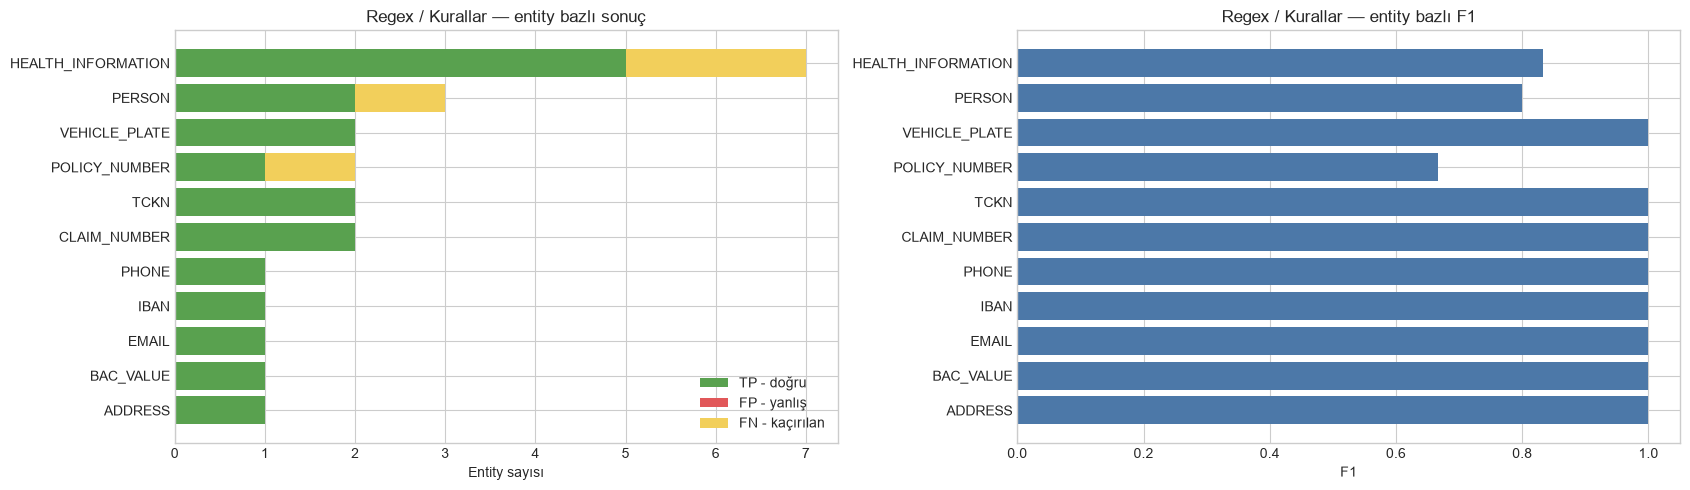

### Kural alt kaynaklarının doğru ve yanlış tespitleri

,run,model_or_source,entity_class,tp,fp
0,Regex / Kurallar,address_rule,ADDRESS,1,0
1,Regex / Kurallar,bac_rule,BAC_VALUE,1,0
2,Regex / Kurallar,health_lexicon,HEALTH_INFORMATION,5,0
3,Regex / Kurallar,person_context_rule,PERSON,2,0
4,Regex / Kurallar,rules,CLAIM_NUMBER,2,0
5,Regex / Kurallar,rules,EMAIL,1,0
6,Regex / Kurallar,rules,IBAN,1,0
7,Regex / Kurallar,rules,PHONE,1,0
8,Regex / Kurallar,rules,POLICY_NUMBER,1,0
9,Regex / Kurallar,rules,TCKN,2,0


In [6]:
RUNS["rules"] = run_condition("Regex / Kurallar", ("rules",))
display_run(RUNS["rules"], "#4C78A8")
if RUNS["rules"]["status"] == "completed" and not RUNS["rules"]["source_df"].empty:
    display(Markdown("### Kural alt kaynaklarının doğru ve yanlış tespitleri"))
    display(RUNS["rules"]["source_df"])

## 7. Microsoft Presidio katmanı

Bu projede Presidio, Türkçe için tanımlanan custom pattern recognizer'ları kullanır. Bu hücre Presidio orkestrasyonunun ve custom recognizer kayıtlarının bağımsız sonucunu ölçer.

Presidio Custom çalışıyor: ('presidio',)


Tamamlandı: 17.976 saniye


,run,engines,documents,gold_entities,predicted_entities,tp,fp,fn,precision,recall,f1,elapsed_seconds
0,Presidio Custom,presidio,17,23,10,10,0,13,1.0,0.4348,0.6061,17.976


,run,entity_class,support,predicted,tp,fp,fn,precision,recall,f1
0,Presidio Custom,ADDRESS,1,0,0,0,1,0.0,0.0,0.0000
1,Presidio Custom,BAC_VALUE,1,0,0,0,1,0.0,0.0,0.0000
2,Presidio Custom,CLAIM_NUMBER,2,2,2,0,0,1.0,1.0,1.0000
3,Presidio Custom,EMAIL,1,1,1,0,0,1.0,1.0,1.0000
4,Presidio Custom,HEALTH_INFORMATION,7,0,0,0,7,0.0,0.0,0.0000
5,Presidio Custom,IBAN,1,1,1,0,0,1.0,1.0,1.0000
6,Presidio Custom,PERSON,3,0,0,0,3,0.0,0.0,0.0000
7,Presidio Custom,PHONE,1,1,1,0,0,1.0,1.0,1.0000
8,Presidio Custom,POLICY_NUMBER,2,1,1,0,1,1.0,0.5,0.6667
9,Presidio Custom,TCKN,2,2,2,0,0,1.0,1.0,1.0000


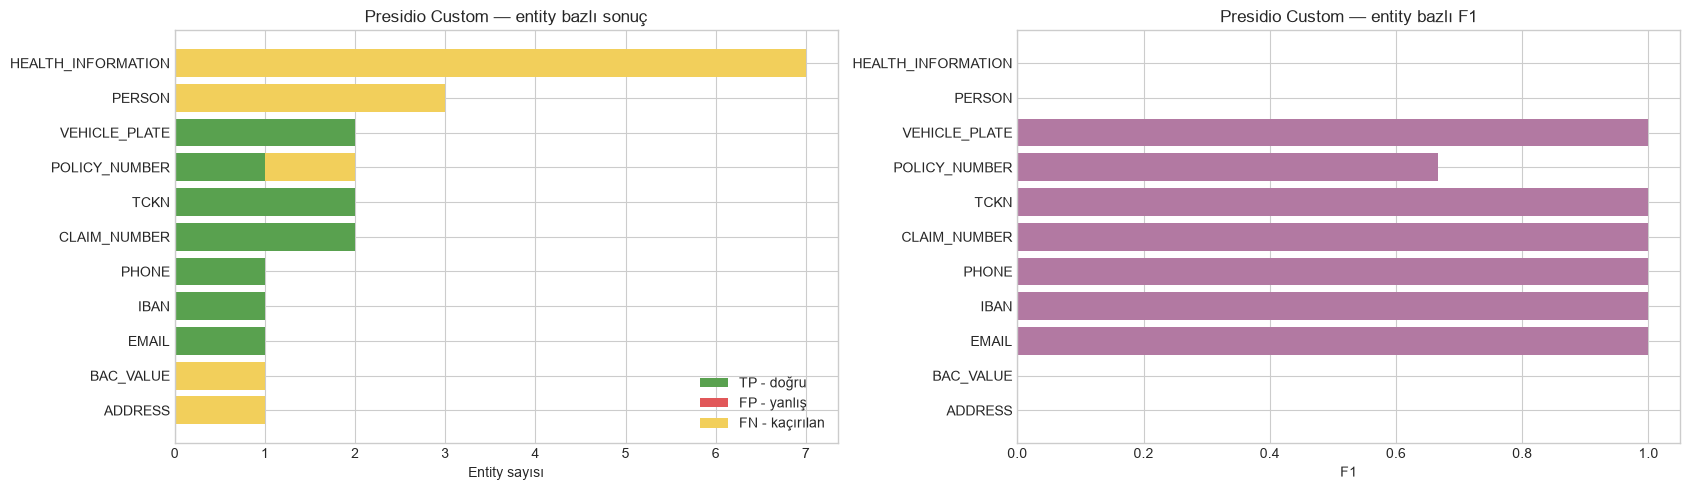

In [7]:
RUNS["presidio"] = run_condition("Presidio Custom", ("presidio",))
display_run(RUNS["presidio"], "#B279A2")

## 8. GLiNER katmanı

Zero-shot entity adları `model_adapters.py` içindeki `GLINER_LABELS` eşlemesinden gelir. Varsayılan model `urchade/gliner_multi-v2.1` modelidir. Buradaki skorlar fine-tune sonucu değildir; mevcut önceden eğitilmiş modelin bağımsız çıkarımıdır.

GLiNER çalışıyor: ('gliner',)


Tamamlandı: 12.467 saniye


,run,engines,documents,gold_entities,predicted_entities,tp,fp,fn,precision,recall,f1,elapsed_seconds
0,GLiNER,gliner,17,23,12,10,2,13,0.8333,0.4348,0.5714,12.467


,run,entity_class,support,predicted,tp,fp,fn,precision,recall,f1
0,GLiNER,ADDRESS,1,1,0,1,1,0.0000,0.0000,0.0000
1,GLiNER,BAC_VALUE,1,1,1,0,0,1.0000,1.0000,1.0000
2,GLiNER,CLAIM_NUMBER,2,0,0,0,2,0.0000,0.0000,0.0000
3,GLiNER,EMAIL,1,0,0,0,1,0.0000,0.0000,0.0000
4,GLiNER,HEALTH_INFORMATION,7,3,2,1,5,0.6667,0.2857,0.4000
5,GLiNER,IBAN,1,1,1,0,0,1.0000,1.0000,1.0000
6,GLiNER,PERSON,3,3,3,0,0,1.0000,1.0000,1.0000
7,GLiNER,PHONE,1,1,1,0,0,1.0000,1.0000,1.0000
8,GLiNER,POLICY_NUMBER,2,1,1,0,1,1.0000,0.5000,0.6667
9,GLiNER,TCKN,2,1,1,0,1,1.0000,0.5000,0.6667


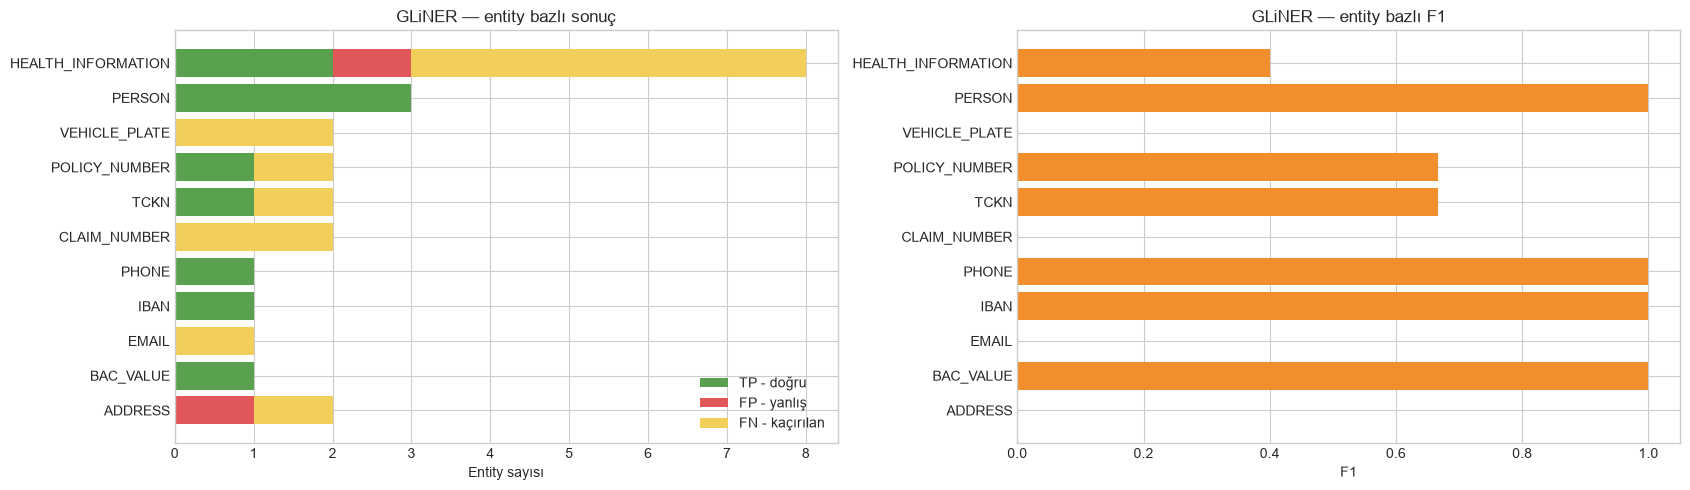

In [8]:
RUNS["gliner"] = run_condition("GLiNER", ("gliner",))
display_run(RUNS["gliner"], "#F28E2B")

## 9. Türkçe NER / ModernBERT katmanı

Projede `ner` adıyla kullanılan varsayılan model `ytu-ce-cosmos/modernbert-tr-pii-ner` modelidir. Modelin ham sınıfları `NER_LABELS` ile ortak entity sınıflarına çevrilir.

Türkçe NER (ModernBERT) çalışıyor: ('ner',)


Tamamlandı: 72.547 saniye


,run,engines,documents,gold_entities,predicted_entities,tp,fp,fn,precision,recall,f1,elapsed_seconds
0,Türkçe NER (ModernBERT),ner,17,23,9,7,2,16,0.7778,0.3043,0.4375,72.547


,run,entity_class,support,predicted,tp,fp,fn,precision,recall,f1
0,Türkçe NER (ModernBERT),ADDRESS,1,2,0,2,1,0.0,0.0000,0.0000
1,Türkçe NER (ModernBERT),BAC_VALUE,1,0,0,0,1,0.0,0.0000,0.0000
2,Türkçe NER (ModernBERT),CLAIM_NUMBER,2,0,0,0,2,0.0,0.0000,0.0000
3,Türkçe NER (ModernBERT),EMAIL,1,0,0,0,1,0.0,0.0000,0.0000
4,Türkçe NER (ModernBERT),HEALTH_INFORMATION,7,0,0,0,7,0.0,0.0000,0.0000
5,Türkçe NER (ModernBERT),IBAN,1,1,1,0,0,1.0,1.0000,1.0000
6,Türkçe NER (ModernBERT),PERSON,3,2,2,0,1,1.0,0.6667,0.8000
7,Türkçe NER (ModernBERT),PHONE,1,1,1,0,0,1.0,1.0000,1.0000
8,Türkçe NER (ModernBERT),POLICY_NUMBER,2,0,0,0,2,0.0,0.0000,0.0000
9,Türkçe NER (ModernBERT),TCKN,2,1,1,0,1,1.0,0.5000,0.6667


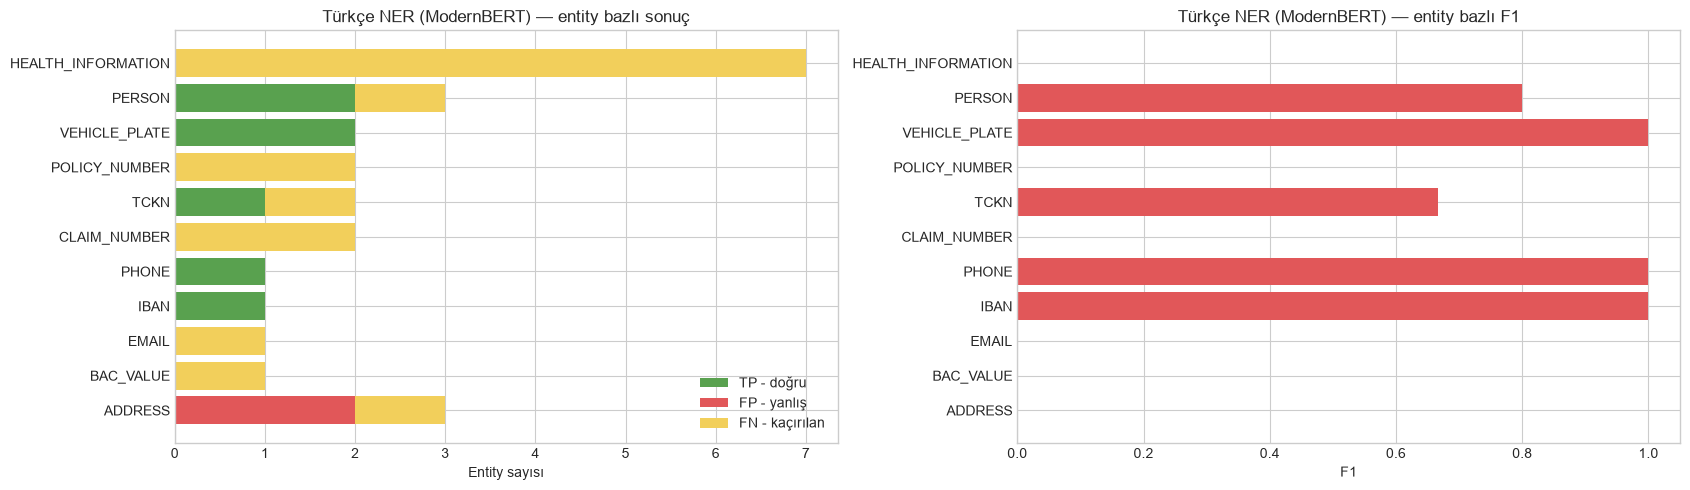

In [9]:
RUNS["ner"] = run_condition("Türkçe NER (ModernBERT)", ("ner",))
display_run(RUNS["ner"], "#E15759")

## 10. İsteğe bağlı yerel LLM ikinci kontrolü

`LOCAL_LLM_MODEL` boş bırakıldığında çağrı yapılmaz. Bir Ollama modeli yazılırsa yalnız inceleme işareti taşıyan metinlerde yerel `127.0.0.1:11434` servisi kullanılır.

In [10]:
if LOCAL_LLM_MODEL:
    RUNS["rules+local_llm"] = run_condition(f"Kurallar + Local LLM ({LOCAL_LLM_MODEL})", ("rules",),
                                                    local_llm_model=LOCAL_LLM_MODEL)
    display_run(RUNS["rules+local_llm"], "#76B7B2")
else:
    display(Markdown("**Atlandı:** `LOCAL_LLM_MODEL = None`. Yerel LLM kullanılmadı."))

**Atlandı:** `LOCAL_LLM_MODEL = None`. Yerel LLM kullanılmadı.

## 11. Modül karşılaştırması

Bu tablo ve grafik yalnız başarıyla tamamlanan koşuları karşılaştırır. Bir model veya paket eksikse ilgili hücrenin hata mesajı korunur ve diğer modüller çalışmaya devam eder.

,run,engines,documents,gold_entities,predicted_entities,tp,fp,fn,precision,recall,f1,elapsed_seconds
0,Regex / Kurallar,rules,17,23,19,19,0,4,1.0000,0.8261,0.9048,0.001
1,Presidio Custom,presidio,17,23,10,10,0,13,1.0000,0.4348,0.6061,17.976
2,GLiNER,gliner,17,23,12,10,2,13,0.8333,0.4348,0.5714,12.467
3,Türkçe NER (ModernBERT),ner,17,23,9,7,2,16,0.7778,0.3043,0.4375,72.547


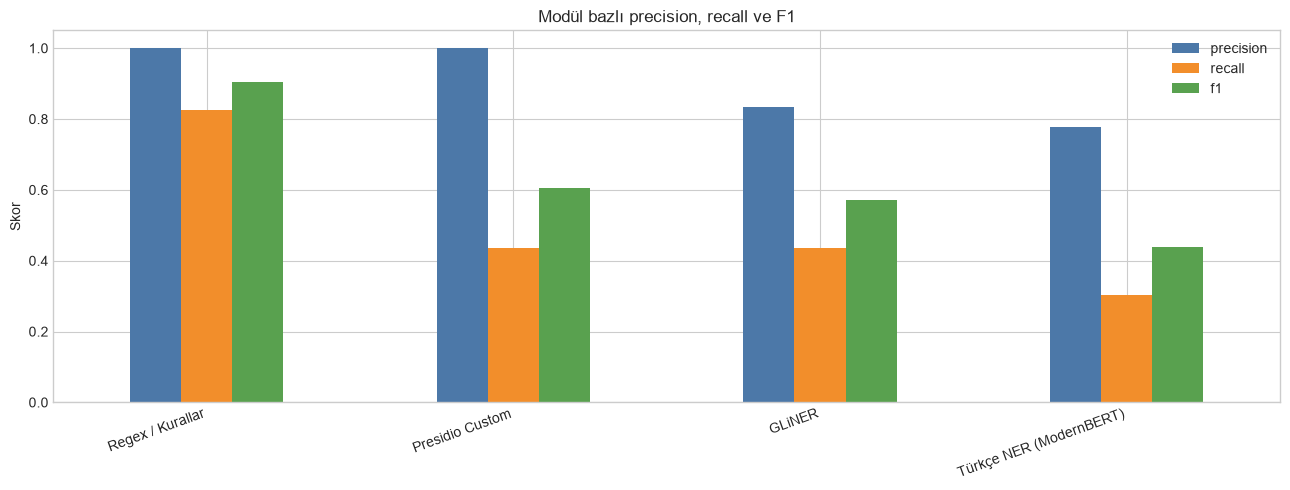

### Her modülün entity sınıfı bazındaki sonuçları

,run,entity_class,support,predicted,tp,fp,fn,precision,recall,f1
22,GLiNER,ADDRESS,1,1,0,1,1,0.0000,0.0000,0.0000
11,Presidio Custom,ADDRESS,1,0,0,0,1,0.0000,0.0000,0.0000
0,Regex / Kurallar,ADDRESS,1,1,1,0,0,1.0000,1.0000,1.0000
33,Türkçe NER (ModernBERT),ADDRESS,1,2,0,2,1,0.0000,0.0000,0.0000
23,GLiNER,BAC_VALUE,1,1,1,0,0,1.0000,1.0000,1.0000
12,Presidio Custom,BAC_VALUE,1,0,0,0,1,0.0000,0.0000,0.0000
1,Regex / Kurallar,BAC_VALUE,1,1,1,0,0,1.0000,1.0000,1.0000
34,Türkçe NER (ModernBERT),BAC_VALUE,1,0,0,0,1,0.0000,0.0000,0.0000
24,GLiNER,CLAIM_NUMBER,2,0,0,0,2,0.0000,0.0000,0.0000
13,Presidio Custom,CLAIM_NUMBER,2,2,2,0,0,1.0000,1.0000,1.0000


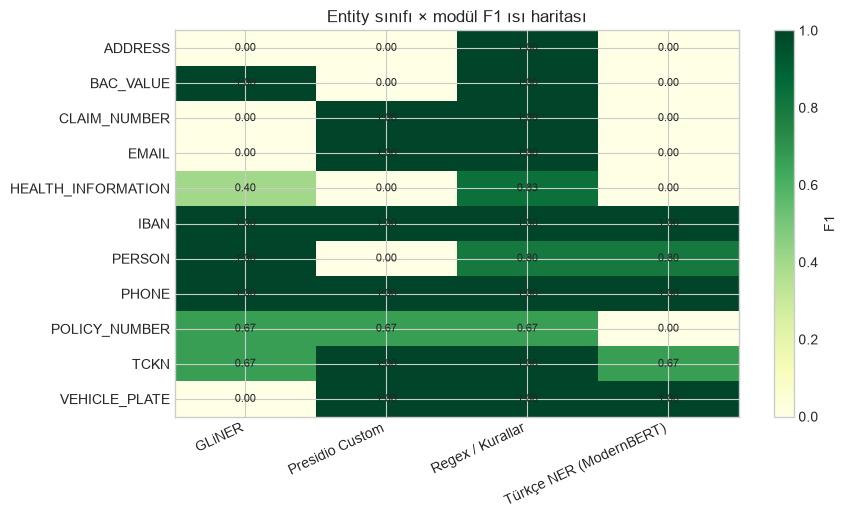

In [11]:
completed_single_runs = [result for result in RUNS.values() if result["status"] == "completed"]
failed_runs_df = pd.DataFrame([{"run": result["name"], "status": result["status"], "error": result["error"]}
                               for result in RUNS.values() if result["status"] != "completed"])
module_comparison_df = pd.DataFrame([result["overall"] for result in completed_single_runs])
display(module_comparison_df.sort_values("f1", ascending=False) if not module_comparison_df.empty else module_comparison_df)
if not failed_runs_df.empty:
    display(Markdown("### Çalıştırılamayan modüller"))
    display(failed_runs_df)
if not module_comparison_df.empty:
    module_comparison_df.set_index("run")[["precision", "recall", "f1"]].plot(
        kind="bar", figsize=(13, 5), ylim=(0, 1.05), color=["#4C78A8", "#F28E2B", "#59A14F"])
    plt.title("Modül bazlı precision, recall ve F1")
    plt.ylabel("Skor")
    plt.xlabel("")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()
module_entity_df = pd.concat([result["entity_df"] for result in completed_single_runs if not result["entity_df"].empty],
                             ignore_index=True) if completed_single_runs else pd.DataFrame()
if not module_entity_df.empty:
    display(Markdown("### Her modülün entity sınıfı bazındaki sonuçları"))
    display(module_entity_df.sort_values(["entity_class", "run"]))
    f1_matrix = module_entity_df.pivot(index="entity_class", columns="run", values="f1").fillna(0)
    fig, ax = plt.subplots(figsize=(max(9, len(f1_matrix.columns) * 2.2), max(5, len(f1_matrix) * 0.48)))
    image = ax.imshow(f1_matrix.values, cmap="YlGn", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(f1_matrix.columns)), f1_matrix.columns, rotation=25, ha="right")
    ax.set_yticks(range(len(f1_matrix.index)), f1_matrix.index)
    for i in range(len(f1_matrix.index)):
        for j in range(len(f1_matrix.columns)):
            ax.text(j, i, f"{f1_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
    ax.set_title("Entity sınıfı × modül F1 ısı haritası")
    fig.colorbar(image, ax=ax, label="F1")
    plt.tight_layout()
    plt.show()

## 12. Hibrit pipeline

Başarıyla çalışan bağımsız katmanlar `rules → presidio → ner → gliner` sırasıyla hibrit koşuya dahil edilir. Pipeline tüm adayları toplar; eşik, yapısal doğrulama, entity önceliği ve kaynak önceliğine göre çakışmaları çözer.

`source` dağılımı, son hibrit çıktıda kabul edilen span'ın kaynağını gösterir. Aynı span birden fazla modül tarafından bulunduğunda yalnız çakışma çözümünü kazanan kaynak görünür.

Hibrit: rules + presidio + ner + gliner çalışıyor: ('rules', 'presidio', 'ner', 'gliner')


Tamamlandı: 2.557 saniye


,run,engines,documents,gold_entities,predicted_entities,tp,fp,fn,precision,recall,f1,elapsed_seconds
0,Hibrit: rules + presidio + ner + gliner,rules+presidio+ner+gliner,17,23,22,22,0,1,1.0,0.9565,0.9778,2.557


,run,entity_class,support,predicted,tp,fp,fn,precision,recall,f1
0,Hibrit: rules + presidio + ner + gliner,ADDRESS,1,1,1,0,0,1.0,1.0000,1.0000
1,Hibrit: rules + presidio + ner + gliner,BAC_VALUE,1,1,1,0,0,1.0,1.0000,1.0000
2,Hibrit: rules + presidio + ner + gliner,CLAIM_NUMBER,2,2,2,0,0,1.0,1.0000,1.0000
3,Hibrit: rules + presidio + ner + gliner,EMAIL,1,1,1,0,0,1.0,1.0000,1.0000
4,Hibrit: rules + presidio + ner + gliner,HEALTH_INFORMATION,7,6,6,0,1,1.0,0.8571,0.9231
5,Hibrit: rules + presidio + ner + gliner,IBAN,1,1,1,0,0,1.0,1.0000,1.0000
6,Hibrit: rules + presidio + ner + gliner,PERSON,3,3,3,0,0,1.0,1.0000,1.0000
7,Hibrit: rules + presidio + ner + gliner,PHONE,1,1,1,0,0,1.0,1.0000,1.0000
8,Hibrit: rules + presidio + ner + gliner,POLICY_NUMBER,2,2,2,0,0,1.0,1.0000,1.0000
9,Hibrit: rules + presidio + ner + gliner,TCKN,2,2,2,0,0,1.0,1.0000,1.0000


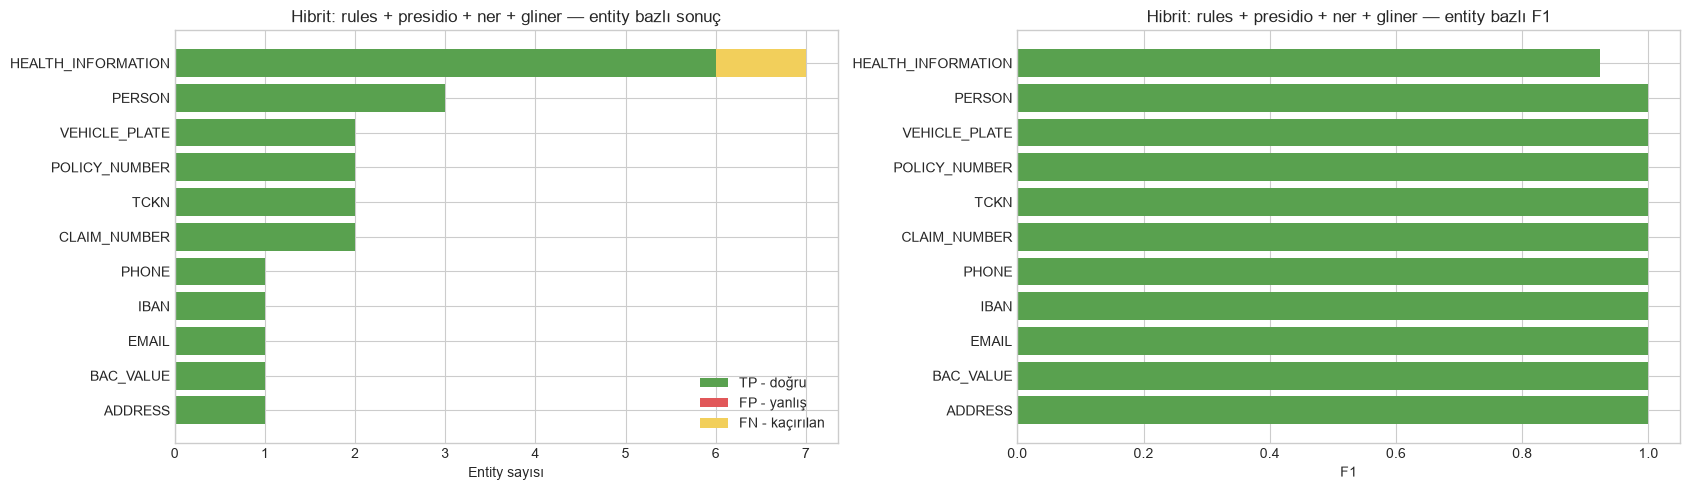

### Hibrit sonuçta kazanan kaynakların katkısı

,model_or_source,tp,fp
5,rules,10,0
3,health_lexicon,5,0
2,gliner,3,0
4,person_context_rule,2,0
1,bac_rule,1,0
0,address_rule,1,0


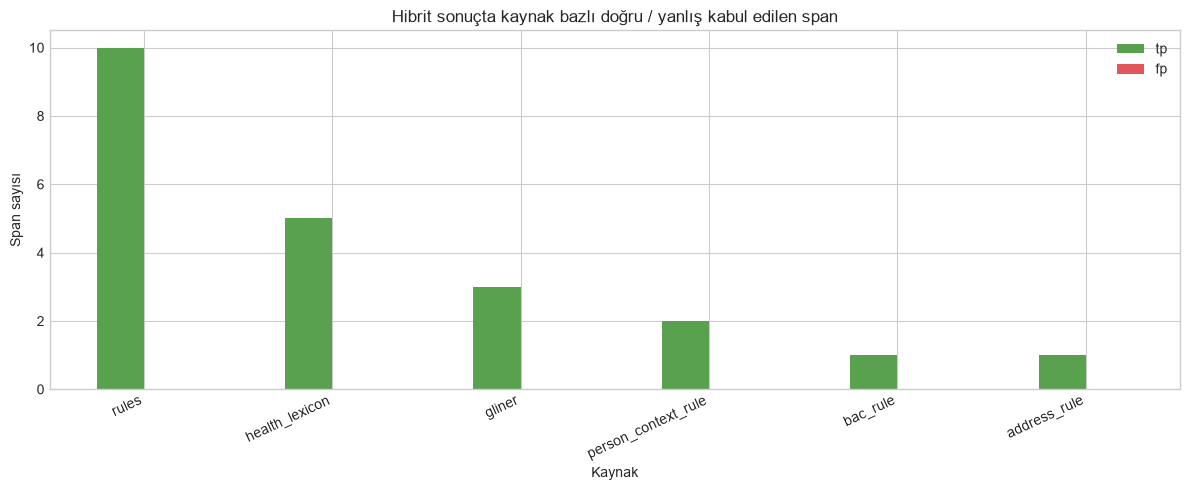

In [12]:
engine_order = ("rules", "presidio", "ner", "gliner")
available_engines = tuple(engine for engine in engine_order
                          if engine in RUNS and RUNS[engine]["status"] == "completed")
if not available_engines:
    raise RuntimeError("Hibrit koşu için çalışan bir algılama katmanı bulunamadı.")
HYBRID = run_condition("Hibrit: " + " + ".join(available_engines), available_engines,
                       local_llm_model=LOCAL_LLM_MODEL)
RUNS["hybrid"] = HYBRID
display_run(HYBRID, "#59A14F")
if HYBRID["status"] == "completed" and not HYBRID["source_df"].empty:
    display(Markdown("### Hibrit sonuçta kazanan kaynakların katkısı"))
    source_summary_df = (HYBRID["source_df"].groupby("model_or_source")[["tp", "fp"]]
                         .sum().reset_index().sort_values("tp", ascending=False))
    display(source_summary_df)
    source_summary_df.set_index("model_or_source")[["tp", "fp"]].plot(
        kind="bar", figsize=(12, 5), color=["#59A14F", "#E15759"])
    plt.title("Hibrit sonuçta kaynak bazlı doğru / yanlış kabul edilen span")
    plt.ylabel("Span sayısı")
    plt.xlabel("Kaynak")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

## 13. Tüm veri setinin maskelenmiş çıktısı ve span JSON'u

Her kayıt için önce maskelenmiş metin, hemen altında kabul edilen entity'lerin JSON listesi gösterilir. Konumlar orijinal metne göredir. JSON içinde ham entity değeri özellikle tutulmaz.

In [13]:
def mask_from_spans(text: str, spans) -> str:
    masked = text
    for span in sorted(spans, key=lambda item: (item.start, item.end), reverse=True):
        masked = masked[:span.start] + f"<{span.label}>" + masked[span.end:]
    return masked


if HYBRID["status"] != "completed":
    raise RuntimeError(f"Hibrit sonuç üretilemedi: {HYBRID['error']}")
MASKED_RESULTS = []
for row in DATASET:
    spans = HYBRID["predictions"][row["_key"]]
    entity_json = [{"start_char": span.start, "end_char": span.end, "model": span.source,
                    "entity_class": span.label, "score": round(span.score, 4)} for span in spans]
    MASKED_RESULTS.append({"id": row["id"], "source_file": row["source_file"],
                           "masked_text": mask_from_spans(row["text"], spans), "entities": entity_json})
for result in MASKED_RESULTS:
    title, masked = escape(f"{result['id']} — {result['source_file']}"), escape(result["masked_text"])
    json_text = escape(json.dumps(result["entities"], ensure_ascii=False, indent=2))
    display(HTML(f"<section style='margin:18px 0;padding:14px;border:1px solid #ddd;border-radius:8px'>"
                 f"<h3 style='margin-top:0'>{title}</h3><p><strong>Maskelenmiş metin</strong></p>"
                 f"<pre style='white-space:pre-wrap'>{masked}</pre><p><strong>Entity JSON</strong></p>"
                 f"<pre>{json_text}</pre></section>"))
print(f"Gösterilen maskelenmiş kayıt sayısı: {len(MASKED_RESULTS)}")

Gösterilen maskelenmiş kayıt sayısı: 17


## 14. Sonuçları dosyaya kaydetme

Oluşturulan dosyalar `outputs/` altında kalır ve mevcut `.gitignore` nedeniyle GitHub'a eklenmez. Maskelenmiş JSONL dosyasında orijinal metin veya ham entity değeri bulunmaz.

In [14]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
masked_path = OUTPUT_DIR / "masked_dataset.jsonl"
with masked_path.open("w", encoding="utf-8") as stream:
    for result in MASKED_RESULTS:
        stream.write(json.dumps(result, ensure_ascii=False) + "\n")
all_completed_runs = [result for result in RUNS.values() if result["status"] == "completed"]
overall_export_df = pd.DataFrame([result["overall"] for result in all_completed_runs])
entity_export_df = pd.concat([result["entity_df"] for result in all_completed_runs if not result["entity_df"].empty],
                             ignore_index=True) if all_completed_runs else pd.DataFrame()
overall_path, entity_path = OUTPUT_DIR / "overall_metrics.csv", OUTPUT_DIR / "entity_metrics.csv"
details_path = OUTPUT_DIR / "evaluation_details.json"
overall_export_df.to_csv(overall_path, index=False, encoding="utf-8-sig")
entity_export_df.to_csv(entity_path, index=False, encoding="utf-8-sig")
details_payload = {result["name"]: {"status": result["status"], "error": result["error"],
                                             "details": result["details"]} for result in RUNS.values()}
details_path.write_text(json.dumps(details_payload, ensure_ascii=False, indent=2), encoding="utf-8")
print("Kaydedilen dosyalar:")
for path in (masked_path, overall_path, entity_path, details_path):
    print(f"- {path.relative_to(ROOT)}")

Kaydedilen dosyalar:
- outputs\notebook_analysis\masked_dataset.jsonl
- outputs\notebook_analysis\overall_metrics.csv
- outputs\notebook_analysis\entity_metrics.csv
- outputs\notebook_analysis\evaluation_details.json


## 15. Sonuçları yorumlarken

- Küçük veri setlerinde birkaç örnek skorları büyük ölçüde değiştirebilir.
- Aynı veri geliştirme sırasında kullanıldıysa sonuçlar bağımsız test başarısı sayılmaz.
- Tam span eşleşmesi katıdır; doğru ifadeyi bir karakter uzun veya kısa bulan model hem `FP` hem `FN` üretir.
- Hibrit kaynak katkısı yalnız son kabul edilen span'ları sayar. Bir entity'yi birden fazla katman bulduysa diğer adaylar birleşme sırasında görünmez.
- `FN`, hibrit kaynaklara dağıtılamaz; bulunmayan bir entity'nin hangi modülün sorumluluğunda olduğu ayrıca yorumlanmalıdır.
- Gerçek üretim değerlendirmesi için kurumdan bağımsız, elle etiketlenmiş ve geliştirme sırasında görülmemiş bir test kümesi kullanılmalıdır.